### Imports

In [21]:
import os
from dotenv import load_dotenv
from typing import TypedDict, List
from langchain_ollama import ChatOllama
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [2]:
load_dotenv(override=True)

True

In [3]:
GEMINI_BASE_URL = "https://generativelanguage.googleapis.com/v1beta/openai/"
OLLAMA_BASE_URL="http://localhost:11434/v1"
OPENROUTER_BASE_URL="https://openrouter.ai/api/v1"
gemini_api_key = os.getenv("GEMINI_API_KEY")
groq_api_key = os.getenv("GROQ_API_KEY")
openrouter_api_key = os.getenv("OPENROUTER_API_KEY")
model = ChatOllama(model="qwen2.5:7b")

## Step 1: State schema
The state is the one object that flows through every LangGraph node. Each node reads some keys and returns the keys it updates.

In [4]:
class ClarifierState(TypedDict):
    raw_text: str
    summary: str
    jargon_terms: List[str]
    explanations: dict
    final_report: str

print("State schema defined:", ClarifierState.__annotations__)

State schema defined: {'raw_text': <class 'str'>, 'summary': <class 'str'>, 'jargon_terms': typing.List[str], 'explanations': <class 'dict'>, 'final_report': <class 'str'>}


In [6]:
model = init_chat_model("ollama:qwen2.5:7b")
print("Model ready:", model)

Model ready: output_version=None model='qwen2.5:7b'


## Step 2: LangChain chains
Four independent `prompt | model` chains. Test each one on its own before wiring them into a graph.

In [ ]:
model = init_chat_model("anthropic:claude-sonnet-4-6", temperature=0)
print("Model ready:", model)

### 2a. Summarizer

In [7]:
SUMMARIZER_PROMPT = ChatPromptTemplate.from_messages([
    ("system", "You write concise, faithful 3-5 sentence summaries of articles. No editorializing, no fluff."),
    ("human", "Summarize this article:\n\n{raw_text}"),
])

def summarize(raw_text: str) -> str:
    chain = SUMMARIZER_PROMPT | model
    return chain.invoke({"raw_text": raw_text}).content

### 2b. Jargon Detector
Uses `with_structured_output` so we get a real Python list back, not text to parse.

In [9]:
class JargonTerms(BaseModel):
    terms: List[str] = Field(description="Technical terms a casual reader might not know. Empty list if none.")

JARGON_PROMPT = ChatPromptTemplate.from_messages([
    ("system", "You identify jargon, acronyms, and specialized concepts in a summary that a general audience might not understand. Be selective."),
    ("human", "Summary:\n\n{summary}"),
])

def detect_jargon(summary: str) -> List[str]:
    structured_model = model.with_structured_output(JargonTerms)
    chain = JARGON_PROMPT | structured_model
    result: JargonTerms = chain.invoke({"summary": summary})
    return result.terms

### 2c. Explainer

In [10]:
EXPLAINER_PROMPT = ChatPromptTemplate.from_messages([
    ("system", "You explain technical terms in a single simple sentence, suitable for someone with no background in the subject."),
    ("human", "Explain this term simply: {term}"),
])

def explain_term(term: str) -> str:
    chain = EXPLAINER_PROMPT | model
    return chain.invoke({"term": term}).content

### 2d. Final Synthesizer

In [11]:
SYNTHESIZER_PROMPT = ChatPromptTemplate.from_messages([
    ("system", "You merge a summary and a glossary of terms into one clean briefing. Use a '## Summary' section and, if there are terms, a '## Key Terms' bullet list."),
    ("human", "Summary:\n{summary}\n\nGlossary (may be empty):\n{glossary}"),
])

def synthesize(summary: str, explanations: dict) -> str:
    glossary = "\n".join(f"- {term}: {defn}" for term, defn in explanations.items())
    chain = SYNTHESIZER_PROMPT | model
    return chain.invoke({"summary": summary, "glossary": glossary or "(none)"}).content

In [ ]:
sample_text = '''
Researchers achieved a 31% power conversion efficiency in a tandem perovskite-silicon solar cell.
Unlike monocrystalline silicon, perovskite layers use low-temperature solution processing, cutting costs.
Stability remains a challenge due to hysteresis effects and ion migration in the crystal lattice.
'''

test_summary = summarize(sample_text)
print("SUMMARY:\n", test_summary)

Failed to get info from https://api.smith.langchain.com: LangSmithConnectionError('Connection error caused failure to GET /info in LangSmith API. Please confirm your internet connection. SSLError(MaxRetryError("HTTPSConnectionPool(host=\'api.smith.langchain.com\', port=443): Max retries exceeded with url: /info (Caused by SSLError(SSLCertVerificationError(1, \'[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)\')))"))\nContent-Length: None\nAPI Key: lsv2_********************************************87')
Run compression is not enabled. Please update to the latest version of LangSmith. Falling back to regular multipart ingestion.


SUMMARY:
 Researchers have developed a tandem perovskite-silicon solar cell with a 31% power conversion efficiency. This approach uses low-temperature solution processing for perovskite layers, reducing costs compared to monocrystalline silicon. However, stability issues persist due to hysteresis effects and ion migration in the perovskite crystal lattice.


Failed to multipart ingest runs: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. SSLError(MaxRetryError("HTTPSConnectionPool(host='api.smith.langchain.com', port=443): Max retries exceeded with url: /runs/multipart (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)')))"))
Content-Length: 9259
API Key: lsv2_********************************************87trace=01a05789-d656-7080-a638-06b9171345e5,id=01a05789-d656-7080-a638-06b9171345e5; trace=01a05789-d656-7080-a638-06b9171345e5,id=01a05789-d902-7e33-a3bc-7e8969df280b; trace=01a05789-d656-7080-a638-06b9171345e5,id=01a05789-dfe9-7521-8afb-15d5d1d3c312
Failed to multipart ingest runs: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. SSLErro

In [14]:
test_terms = detect_jargon(test_summary)
print("JARGON TERMS:", test_terms)

JARGON TERMS: ['perovskite-silicon solar cell', 'tandem solar cell', 'power conversion efficiency', 'low-temperature solution processing', 'hysteresis effects', 'ion migration']


Failed to multipart ingest runs: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. SSLError(MaxRetryError("HTTPSConnectionPool(host='api.smith.langchain.com', port=443): Max retries exceeded with url: /runs/multipart (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)')))"))
Content-Length: 10257
API Key: lsv2_********************************************87trace=01a0578b-2212-7a71-89a2-74595616de5a,id=01a0578b-2212-7a71-89a2-74595616de5a; trace=01a0578b-2212-7a71-89a2-74595616de5a,id=01a0578b-2213-75c0-9612-841f67c9ff9d; trace=01a0578b-2212-7a71-89a2-74595616de5a,id=01a0578b-2232-7460-b5a5-d134d7c2337f


In [ ]:
test_explanations = {t: explain_term(t) for t in test_terms}
for term, defn in test_explanations.items():
    print(f"- {term}: {defn}")

Failed to multipart ingest runs: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. SSLError(MaxRetryError("HTTPSConnectionPool(host='api.smith.langchain.com', port=443): Max retries exceeded with url: /runs/multipart (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)')))"))
Content-Length: 10735
API Key: lsv2_********************************************87trace=01a0578b-2212-7a71-89a2-74595616de5a,id=01a0578b-40fe-7d50-a72c-9cca86097a0e; trace=01a0578b-2212-7a71-89a2-74595616de5a,id=01a0578b-2212-7a71-89a2-74595616de5a; trace=01a0578b-2212-7a71-89a2-74595616de5a,id=01a0578b-2232-7460-b5a5-d134d7c2337f


- perovskite-silicon solar cell: A perovskite-silicon solar cell combines materials called perovskite and silicon to capture sunlight and convert it into electricity more efficiently.
- tandem solar cell: A tandem solar cell is a solar panel that stacks different layers of materials to capture light at various wavelengths more efficiently.
- power conversion efficiency: Power conversion efficiency is how well a device changes the energy it gets into useful work, expressed as a percentage.
- low-temperature solution processing: Low-temperature solution processing is a method of making materials or devices, like solar cells, by using liquids and doing it at not-too-hot temperatures, usually below 100°C.
- hysteresis effects: Hysteresis effects are when the response of a system depends not only on the current input but also on the history of that input.
- ion migration: Ion migration is the movement of charged particles (ions) from one place to another, often due to an electric field.


Failed to multipart ingest runs: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. SSLError(MaxRetryError("HTTPSConnectionPool(host='api.smith.langchain.com', port=443): Max retries exceeded with url: /runs/multipart (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)')))"))
Content-Length: 29252
API Key: lsv2_********************************************87trace=01a0578b-67b5-71e3-860a-47a665689066,id=01a0578b-67b5-71e3-860a-47a665689066; trace=01a0578b-67b5-71e3-860a-47a665689066,id=01a0578b-67b6-7342-a9da-e6702833b5e5; trace=01a0578b-67b5-71e3-860a-47a665689066,id=01a0578b-67b6-7342-a9da-e6811ca4fa01; trace=01a0578b-7e31-7941-bf71-afd9640e8857,id=01a0578b-7e31-7941-bf71-afd9640e8857; trace=01a0578b-7e31-7941-bf71-afd9640e8857,id=01a0578b-7e31-7941-bf71-afe7d3129021; trace=01a0578b-7

In [16]:
test_report = synthesize(test_summary, test_explanations)
print(test_report)

Failed to multipart ingest runs: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. SSLError(MaxRetryError("HTTPSConnectionPool(host='api.smith.langchain.com', port=443): Max retries exceeded with url: /runs/multipart (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)')))"))
Content-Length: 13704
API Key: lsv2_********************************************87trace=01a0578f-c2d6-72d3-9fb6-023b2c2bb0f1,id=01a0578f-c2d6-72d3-9fb6-023b2c2bb0f1; trace=01a0578f-c2d6-72d3-9fb6-023b2c2bb0f1,id=01a0578f-c2d7-7770-91a7-8d2c8db9342e; trace=01a0578f-c2d6-72d3-9fb6-023b2c2bb0f1,id=01a0578f-c2d9-7791-ba5d-78c5d48810c2


## Summary
Researchers have developed a tandem perovskite-silicon solar cell with a 31% power conversion efficiency. This approach uses low-temperature solution processing for perovskite layers, which reduces costs compared to monocrystalline silicon. However, stability issues persist due to hysteresis effects and ion migration in the perovskite crystal lattice.

## Key Terms
- **perovskite-silicon solar cell**: A perovskite-silicon solar cell combines materials called perovskite and silicon to capture sunlight and convert it into electricity more efficiently.
- **tandem solar cell**: A tandem solar cell is a solar panel that stacks different layers of materials to capture light at various wavelengths more efficiently.
- **power conversion efficiency**: Power conversion efficiency is how well a device changes the energy it gets into useful work, expressed as a percentage.
- **low-temperature solution processing**: Low-temperature solution processing is a method of making materials or d

Failed to multipart ingest runs: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. SSLError(MaxRetryError("HTTPSConnectionPool(host='api.smith.langchain.com', port=443): Max retries exceeded with url: /runs/multipart (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1010)')))"))
Content-Length: 13364
API Key: lsv2_********************************************87trace=01a0578f-c2d6-72d3-9fb6-023b2c2bb0f1,id=01a0578f-c2d6-72d3-9fb6-023b2c2bb0f1; trace=01a0578f-c2d6-72d3-9fb6-023b2c2bb0f1,id=01a0578f-c2d9-7791-ba5d-78c5d48810c2


## Step 3: LangGraph
Wrap the four chains as nodes. Add a conditional edge that skips the explainer when there's no jargon.

```
summarizer -> jargon_detector --(has jargon?)--> explainer -> synthesizer -> END
                               \--(no jargon)--------------> synthesizer -> END
```

In [18]:
def summarizer_node(state: ClarifierState) -> dict:
    return {"summary": summarize(state["raw_text"])}

def jargon_detector_node(state: ClarifierState) -> dict:
    return {"jargon_terms": detect_jargon(state["summary"])}

def explainer_node(state: ClarifierState) -> dict:
    return {"explanations": {t: explain_term(t) for t in state["jargon_terms"]}}

def synthesizer_node(state: ClarifierState) -> dict:
    return {"final_report": synthesize(state["summary"], state.get("explanations", {}))}

def has_jargon(state: ClarifierState) -> str:
    return "explain" if state["jargon_terms"] else "skip"

print("Node functions defined")

Node functions defined


In [19]:
graph = StateGraph(ClarifierState)

graph.add_node("summarizer", summarizer_node)
graph.add_node("jargon_detector", jargon_detector_node)
graph.add_node("explainer", explainer_node)
graph.add_node("synthesizer", synthesizer_node)

graph.add_edge(START, "summarizer")
graph.add_edge("summarizer", "jargon_detector")
graph.add_conditional_edges(
    "jargon_detector",
    has_jargon,
    {"explain": "explainer", "skip": "synthesizer"},
)
graph.add_edge("explainer", "synthesizer")
graph.add_edge("synthesizer", END)

app = graph.compile()
print("Graph compiled. Nodes:", list(app.get_graph().nodes.keys()))

Graph compiled. Nodes: ['__start__', 'summarizer', 'jargon_detector', 'explainer', 'synthesizer', '__end__']


### Optional: visualize the graph
Render a PNG via Mermaid if you have the extra installed.

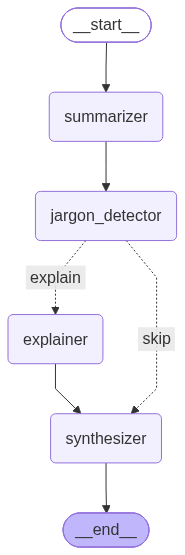

In [26]:
display(Image(app.get_graph().draw_mermaid_png()))

## Step 4: Run the full graph end-to-end

In [27]:
result = app.invoke({"raw_text": sample_text})

print(result["final_report"])
print()
if result.get("jargon_terms"):
    print(f"(Detected {len(result['jargon_terms'])} jargon terms: {', '.join(result['jargon_terms'])})")
else:
    print("(No jargon detected — explainer step was skipped)")

## Summary
Researchers have developed a tandem perovskite-silicon solar cell with a 31% power conversion efficiency. This innovative method employs low-temperature solution processing for the perovskite layers, reducing costs compared to the more conventional monocrystalline silicon. However, the system still faces challenges in terms of stability, primarily due to hysteresis effects and ion migration within the perovskite crystal lattice.

## Key Terms
- **tandem perovskite-silicon solar cell**: A solar panel that stacks a perovskite layer on top of a silicon layer to capture more sunlight and improve overall efficiency.
- **power conversion efficiency**: The measure of how well a device converts input energy into usable power, expressed as a percentage.
- **low-temperature solution processing**: A method of manufacturing materials or devices, like solar cells, by combining substances in a liquid form at low temperatures to reduce the need for high-temperature processes and lower cost